In [1]:
import os, random, math, time, json, signal, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

os.environ['CUDA_LAUNCH_BLOCKING'] = "0"      # keep 0 in production; set 1 only when debugging CUDA errors

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# A100 TF32 – gives ~2× matmul throughput vs fp32 with negligible accuracy loss
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32        = True
torch.backends.cudnn.benchmark         = True   # auto-tune conv kernels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.cuda.empty_cache()

Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/

dataset_combined.zip  datasetfilnal_v3.zip  final_dataset_vsl.zip
datasetfilnal_v2.zip  dataset.zip


In [4]:
# !rm -rf /content/SignDETR-VSL



In [5]:
import os
import shutil
import zipfile

# Khai báo các đường dẫn
source_path = '/content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/datasetfilnal_v3.zip'
dest_zip = '/content/datasetfilnal_v3.zip'
extract_dir = '/content/SignDETR-VSL'

# 1. Kiểm tra xem thư mục đích đã tồn tại và có dữ liệu bên trong chưa
if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
    print("✅ Dataset đã được giải nén sẵn trong máy. Bỏ qua bước copy và unzip!")
else:
    print("⚠️ Chưa có dataset sẵn sàng. Bắt đầu xử lý...")

    # 2. Kiểm tra xem file zip đã được copy xuống Colab chưa
    if not os.path.exists(dest_zip):
        print("⏳ Đang copy file zip từ Google Drive xuống...")
        if os.path.exists(source_path):
            shutil.copy(source_path, dest_zip)
            print("✅ Copy từ Drive hoàn tất!")
        else:
            print("❌ LỖI: Không tìm thấy file zip trên Drive. Bạn đã mount Drive chưa?")
            raise FileNotFoundError("Không tìm thấy file trên Google Drive.")
    else:
        print("✅ File zip đã có sẵn ở '/content/'. Bỏ qua bước copy từ Drive.")

    # 3. Tiến hành giải nén
    print("⏳ Đang tiến hành giải nén...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(dest_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print("🎉 Hoàn tất chuẩn bị dữ liệu!")

⚠️ Chưa có dataset sẵn sàng. Bắt đầu xử lý...
⏳ Đang copy file zip từ Google Drive xuống...
✅ Copy từ Drive hoàn tất!
⏳ Đang tiến hành giải nén...
🎉 Hoàn tất chuẩn bị dữ liệu!


In [6]:
import os

ROOT = "/content/SignDETR-VSL"
splits = ["train", "valid", "test"]

def count_files(path, exts):
    return len([f for f in os.listdir(path) if f.lower().endswith(exts)])

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    n_imgs = count_files(img_dir, (".jpg", ".png", ".jpeg"))
    n_lbls = count_files(lbl_dir, (".txt",))

    print(f"{split.upper():5} | images: {n_imgs:5} | labels: {n_lbls:5}")


TRAIN | images:  2139 | labels:  2139
VALID | images:   616 | labels:   616
TEST  | images:   330 | labels:   330


In [7]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [8]:
!find /content/SignDETR-VSL -maxdepth 2 -type d


/content/SignDETR-VSL
/content/SignDETR-VSL/train
/content/SignDETR-VSL/train/images
/content/SignDETR-VSL/train/labels
/content/SignDETR-VSL/valid
/content/SignDETR-VSL/valid/images
/content/SignDETR-VSL/valid/labels
/content/SignDETR-VSL/test
/content/SignDETR-VSL/test/images
/content/SignDETR-VSL/test/labels


In [9]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [10]:
import os
import cv2
import matplotlib.pyplot as plt

LABEL_ID = 5  # đổi nhãn bạn muốn xem

IMG_DIR = "/content/SignDETR-VSL/train/images"
LBL_DIR = "/content/SignDETR-VSL/train/labels"

images_with_label = []

for lbl_file in os.listdir(LBL_DIR):
    lbl_path = os.path.join(LBL_DIR, lbl_file)
    with open(lbl_path, "r") as f:
        for line in f:
            if int(line.split()[0]) == LABEL_ID:
                img_name = lbl_file.replace(".txt", ".jpg")  # hoặc .png
                images_with_label.append(img_name)
                break

print(f"Tìm thấy {len(images_with_label)} ảnh có nhãn {LABEL_ID}")

Tìm thấy 97 ảnh có nhãn 5


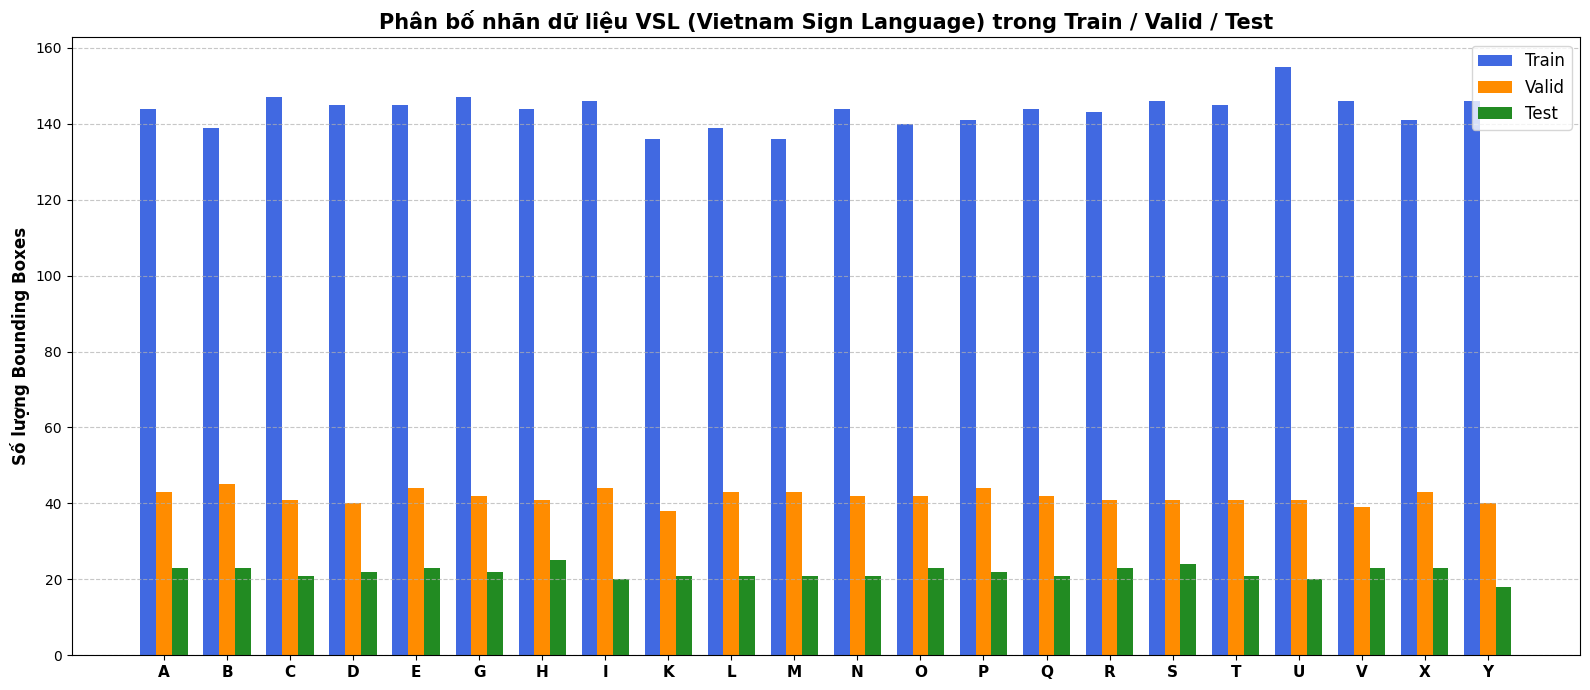


✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "/content/SignDETR-VSL/"
splits = ['train', 'valid', 'test']
CLASSES = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']
# Khởi tạo dictionary để đếm số lượng bbox
counts = {split: {i: 0 for i in range(len(CLASSES))} for split in splits}
invalid_labels = []

# Quét file labels
for split in splits:
    lbl_dir = os.path.join(DATA_DIR, split, 'labels')
    if not os.path.exists(lbl_dir):
        continue

    for file in os.listdir(lbl_dir):
        if file.endswith('.txt'):
            with open(os.path.join(lbl_dir, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        cls_id = int(parts[0])
                        # Nếu ID nằm trong danh sách chuẩn
                        if 0 <= cls_id < len(CLASSES):
                            counts[split][cls_id] += 1
                        else:
                            invalid_labels.append((split, file, cls_id))

# Vẽ biểu đồ
x = np.arange(len(CLASSES))
width = 0.25  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(16, 7))

train_counts = [counts['train'][i] for i in range(len(CLASSES))]
valid_counts = [counts['valid'][i] for i in range(len(CLASSES))]
test_counts = [counts['test'][i] for i in range(len(CLASSES))]

# Tạo các cột
rects1 = ax.bar(x - width, train_counts, width, label='Train', color='royalblue')
rects2 = ax.bar(x, valid_counts, width, label='Valid', color='darkorange')
rects3 = ax.bar(x + width, test_counts, width, label='Test', color='forestgreen')

# Trang trí biểu đồ
ax.set_ylabel('Số lượng Bounding Boxes', fontsize=12, fontweight='bold')
ax.set_title('Phân bố nhãn dữ liệu VSL (Vietnam Sign Language) trong Train / Valid / Test', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=11, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# In cảnh báo nếu có nhãn rác
if invalid_labels:
    print("\n⚠️ CẢNH BÁO: Phát hiện các nhãn rác (ID >= 23 hoặc < 0) trong Dataset!")
    print(f"Tổng số nhãn rác: {len(invalid_labels)}")
    print("5 ví dụ đầu tiên:", invalid_labels[:5])
else:
    print("\n✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.")

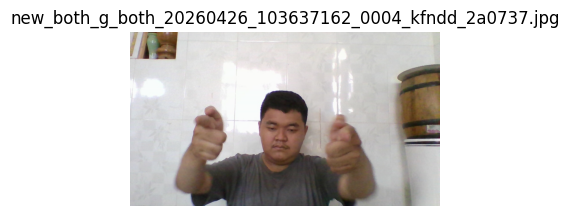

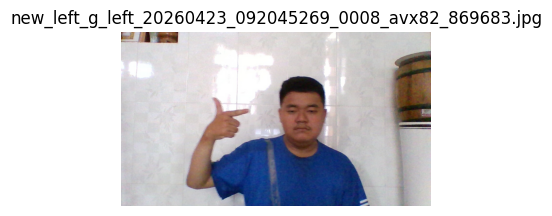

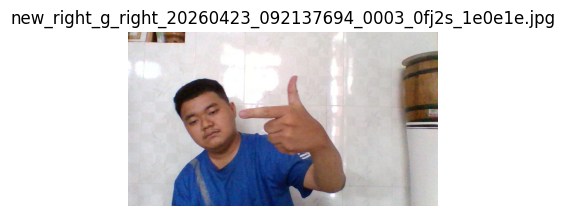

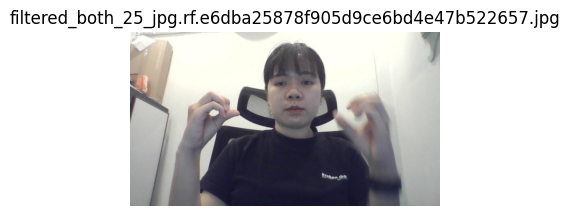

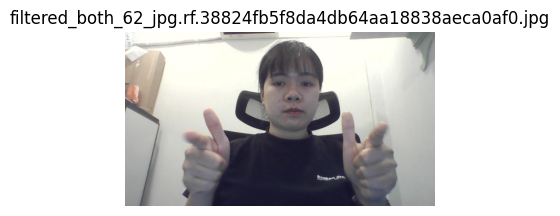

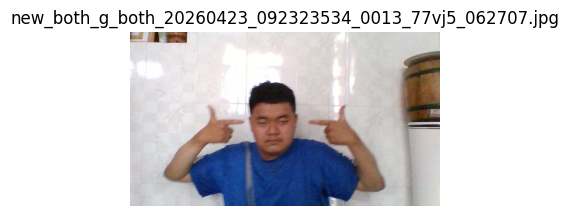

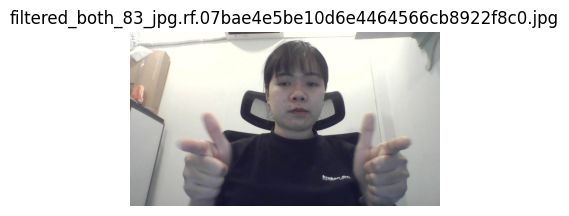

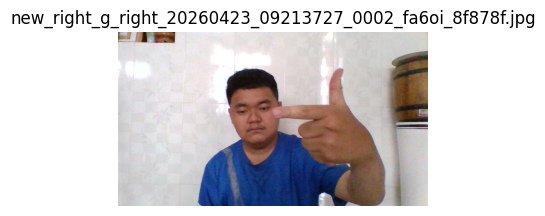

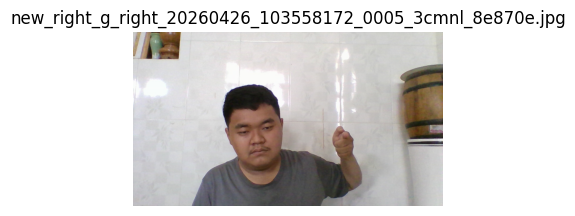

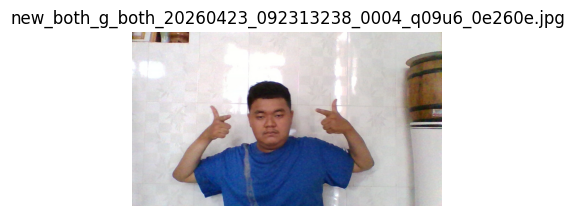

In [12]:
import os
import cv2
import matplotlib.pyplot as plt

for img_name in images_with_label[:10]:
    img_path = os.path.join(IMG_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

In [13]:
def draw_yolo_bbox(img, label_path):
    h, w, _ = img.shape
    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    return img

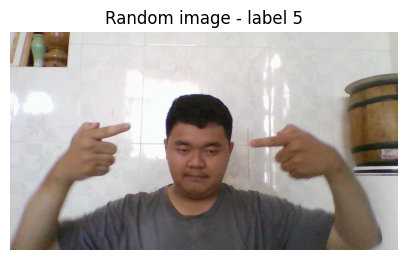

In [14]:
import random

random_img = random.choice(images_with_label)

img_path = os.path.join(IMG_DIR, random_img)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Random image - label {LABEL_ID}")
plt.show()

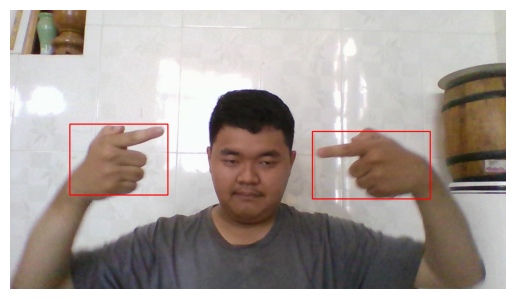

In [15]:
lbl_path = os.path.join(LBL_DIR, random_img.replace(".jpg", ".txt"))
img_box = draw_yolo_bbox(img.copy(), lbl_path)

plt.imshow(img_box)
plt.axis("off")
plt.show()

In [16]:
import subprocess, sys

for pkg in ['albumentations', 'colorama', 'rich', 'torchinfo', 'scipy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [17]:
CLASSES = ['A','B','C','D','E','G','H','I','K','L',
           'M','N','O','P','Q','R','S','T','U','V','X','Y']
NUM_CLASSES = len(CLASSES)                       # 22
id2name = {i: n for i, n in enumerate(CLASSES)}
name2id = {n: i for i, n in enumerate(CLASSES)}

## mô hình DETR

In [18]:
def _get_1d_sincos_pos_embed(length, dim, temperature=10000.0, device=None):
    assert dim % 2 == 0
    pos  = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div  = torch.exp(torch.arange(0, dim, 2, device=device, dtype=torch.float32)
                     * (-math.log(temperature) / dim))
    pe   = torch.zeros(length, dim, device=device)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

def build_2d_sincos_pos_embed(H, W, dim, device=None):
    assert dim % 2 == 0
    d = dim // 2
    pe_y = _get_1d_sincos_pos_embed(H, d, device=device)  # (H, d)
    pe_x = _get_1d_sincos_pos_embed(W, d, device=device)  # (W, d)
    pos  = torch.zeros(H, W, dim, device=device)
    pos[:, :, :d] = pe_y[:, None, :].expand(-1, W, -1)
    pos[:, :, d:] = pe_x[None, :, :].expand(H, -1, -1)
    return pos.view(1, H * W, dim)                         # (1, HW, dim)

In [19]:
# 5. CUSTOM TRANSFORMER DECODER WITH INTERMEDIATE OUTPUTS
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn   = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff1          = nn.Linear(d_model, dim_feedforward)
        self.ff2          = nn.Linear(dim_feedforward, d_model)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.norm3       = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)
        self.act         = nn.GELU()

    def forward(self, tgt, memory, query_pos, pos):
        # self-attention on queries
        q = k = tgt + query_pos
        tgt2, _ = self.self_attn(q, k, tgt)
        tgt  = self.norm1(tgt + self.dropout(tgt2))
        # cross-attention to encoder memory
        tgt2, _ = self.cross_attn(tgt + query_pos, memory + pos, memory)
        tgt  = self.norm2(tgt + self.dropout(tgt2))
        # feed-forward
        tgt2 = self.ff2(self.dropout(self.act(self.ff1(tgt))))
        tgt  = self.norm3(tgt + self.dropout(tgt2))
        return tgt


class TransformerDecoder(nn.Module):
    """Returns a list of intermediate outputs (one per layer)."""
    def __init__(self, decoder_layer, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(decoder_layer) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(decoder_layer.ff2.out_features)

    def forward(self, tgt, memory, query_pos, pos):
        out, intermediates = tgt, []
        for layer in self.layers:
            out = layer(out, memory, query_pos, pos)
            intermediates.append(self.norm(out))
        return torch.stack(intermediates)               # (num_layers, B, Q, d)

In [20]:
# 6. DETR MODEL
from torchvision.models import resnet50, ResNet50_Weights

class DETR(nn.Module):
    def __init__(self,
                 num_classes,
                 hidden_dim       = 256,
                 nheads           = 8,
                 num_encoder_layers = 6,   # default: DETR-paper setting
                 num_decoder_layers = 6,
                 num_queries      = 25,
                 dim_feedforward  = 2048,
                 dropout          = 0.1):
        super().__init__()

        # ── Backbone
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        # keep only feature extractor, drop avg-pool + fc
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )

        # ── Projection: 2048 → hidden_dim
        self.input_proj = nn.Sequential(
            nn.Conv2d(2048, hidden_dim, 1),
            nn.GroupNorm(32, hidden_dim)               # more stable than BN under small batches
        )

        # ── Transformer encoder (standard PyTorch)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nheads,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True)                           # Pre-LN: faster convergence
        self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,
                                              norm=nn.LayerNorm(hidden_dim))

        # ── Transformer decoder (custom, returns intermediates) ─
        dec_layer = TransformerDecoderLayer(hidden_dim, nheads, dim_feedforward, dropout)
        self.decoder = TransformerDecoder(dec_layer, num_decoder_layers)

        # ── Prediction heads (shared across layers via FFN) ────
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)
        self.bbox_embed  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)
        )

        # ── Learnable query embeddings ─────────────────────────
        self.num_queries = num_queries
        self.query_embed = nn.Embedding(num_queries, hidden_dim)   # [Q, d]

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_proj[0].weight)
        nn.init.constant_(self.input_proj[0].bias, 0)
        nn.init.xavier_uniform_(self.class_embed.weight)
        nn.init.constant_(self.class_embed.bias, 0)
        for m in self.bbox_embed:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # ── 1. Backbone features ───────────────────────────────
        feat = self.backbone(x)                        # (B, 2048, H/32, W/32)
        feat = self.input_proj(feat)                   # (B, d, Hf, Wf)
        B, d, Hf, Wf = feat.shape

        # ── 2. Flatten + positional embedding ─────────────────
        src = feat.flatten(2).permute(0, 2, 1)         # (B, HW, d)
        pos = build_2d_sincos_pos_embed(Hf, Wf, d, device=feat.device)  # (1, HW, d)

        # ── 3. Encoder ─────────────────────────────────────────
        memory = self.encoder(src + pos)               # (B, HW, d)

        # ── 4. Decoder ─────────────────────────────────────────
        tgt        = torch.zeros(B, self.num_queries, d, device=x.device)
        query_pos  = self.query_embed.weight.unsqueeze(0).expand(B, -1, -1)  # (B, Q, d)

        # hs: (num_layers, B, Q, d)
        hs = self.decoder(tgt, memory, query_pos, pos)

        # ── 5. Prediction heads applied to ALL decoder layers ──
        outputs_class = self.class_embed(hs)           # (L, B, Q, num_cls+1)
        outputs_coord = self.bbox_embed(hs).sigmoid()  # (L, B, Q, 4)

        # Primary output = last decoder layer
        out = {
            'pred_logits': outputs_class[-1],
            'pred_boxes':  outputs_coord[-1],
        }

        # Auxiliary outputs (all other layers) for aux loss
        out['aux_outputs'] = [
            {'pred_logits': outputs_class[i], 'pred_boxes': outputs_coord[i]}
            for i in range(len(self.decoder.layers) - 1)
        ]
        return out


In [21]:
# 7. BOX UTILITIES
def box_cxcywh_to_xyxy(x):
    x0, y0, w, h = x.unbind(-1)
    return torch.stack([(x0 - .5*w), (y0 - .5*h), (x0 + .5*w), (y0 + .5*h)], -1)

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2]-boxes1[:, 0]).clamp(0) * (boxes1[:, 3]-boxes1[:, 1]).clamp(0)
    area2 = (boxes2[:, 2]-boxes2[:, 0]).clamp(0) * (boxes2[:, 3]-boxes2[:, 1]).clamp(0)
    lt    = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb    = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh    = (rb - lt).clamp(0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(1e-6), union

def generalized_box_iou(boxes1, boxes2):
    iou, union = box_iou(boxes1, boxes2)
    lt  = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb  = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh  = (rb - lt).clamp(0)
    enc = wh[:, :, 0] * wh[:, :, 1]
    return iou - (enc - union) / enc.clamp(1e-6)

def stacker(batch):
    imgs, tgts = zip(*batch)
    return torch.stack(imgs), list(tgts)

In [22]:
# 8. HUNGARIAN MATCHER

from scipy.optimize import linear_sum_assignment

class HungarianMatcher(nn.Module):
    def __init__(self, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox  = cost_bbox
        self.cost_giou  = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        indices = []
        for i, tgt in enumerate(targets):
            logits = outputs['pred_logits'][i]
            boxes  = outputs['pred_boxes'][i]
            prob   = logits.softmax(-1)

            tgt_labels = tgt['labels'].long()
            tgt_boxes  = tgt['boxes'].float()

            C = (self.cost_bbox  * torch.cdist(boxes, tgt_boxes, p=1)
               + self.cost_class * -prob[:, tgt_labels]
               + self.cost_giou  * -generalized_box_iou(
                   box_cxcywh_to_xyxy(boxes),
                   box_cxcywh_to_xyxy(tgt_boxes)
               )).cpu()

            ii, jj = linear_sum_assignment(C)
            indices.append((torch.as_tensor(ii, dtype=torch.int64),
                            torch.as_tensor(jj, dtype=torch.int64)))
        return indices

In [23]:
# 9. DETR LOSS (with auxiliary decoder losses)
class DETRLoss(nn.Module):
    def __init__(self, num_classes, matcher, eos_coef=0.1,
                 cost_class=1.0, cost_bbox=5.0, cost_giou=2.0,
                 aux_loss_weight=0.5):
        super().__init__()
        self.num_classes      = num_classes
        self.matcher          = matcher
        self.eos_coef         = eos_coef
        self.cost_class       = cost_class
        self.cost_bbox        = cost_bbox
        self.cost_giou        = cost_giou
        self.aux_loss_weight  = aux_loss_weight

        empty_weight          = torch.ones(num_classes + 1)
        empty_weight[-1]      = eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def _classification_loss(self, outputs, targets, indices):
        src_logits = outputs['pred_logits']
        idx = self._get_src_permutation_idx(indices)
        tgt_cls_o = torch.cat([t['labels'][J] for t, (_, J) in zip(targets, indices)])
        tgt_cls   = torch.full(src_logits.shape[:2], self.num_classes,
                               dtype=torch.int64, device=src_logits.device)
        tgt_cls[idx] = tgt_cls_o
        return F.cross_entropy(src_logits.transpose(1, 2), tgt_cls, self.empty_weight)

    def _box_loss(self, outputs, targets, indices, num_boxes):
        idx       = self._get_src_permutation_idx(indices)
        src_boxes = outputs['pred_boxes'][idx]
        tgt_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], 0)
        l1        = F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum() / num_boxes
        giou      = (1 - torch.diag(generalized_box_iou(
                         box_cxcywh_to_xyxy(src_boxes),
                         box_cxcywh_to_xyxy(tgt_boxes)))).sum() / num_boxes
        return l1, giou

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx   = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def _single_loss(self, outputs, targets):
        targets  = [{'labels': t['labels'].long(), 'boxes': t['boxes'].float()} for t in targets]
        indices  = self.matcher(outputs, targets)
        num_boxes = max(sum(len(t['labels']) for t in targets), 1)
        ce       = self._classification_loss(outputs, targets, indices)
        l1, giou = self._box_loss(outputs, targets, indices, num_boxes)
        return (self.cost_class * ce + self.cost_bbox * l1 + self.cost_giou * giou,
                ce, l1, giou)

    def forward(self, outputs, targets):
        total, ce, l1, giou = self._single_loss(outputs, targets)

        # Auxiliary losses from intermediate decoder layers
        aux_total = 0.0
        for aux_out in outputs.get('aux_outputs', []):
            a, _, _, _ = self._single_loss(aux_out, targets)
            aux_total += a
        if outputs.get('aux_outputs'):
            aux_total /= len(outputs['aux_outputs'])

        loss = total + self.aux_loss_weight * aux_total
        return loss, ce, l1, giou

In [24]:
# 10. DATASET
import glob
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

class DETRData(Dataset):
    def __init__(self, path, train=True):
        self.images_path = os.path.join(path, 'images')
        self.labels_path = os.path.join(path, 'labels')
        self.train = train
        self.labels = [f for f in os.listdir(self.labels_path) if f.endswith('.txt')]

    # ── Augmentation pipelines
    def _build_train_transform(self):
        return A.Compose([
            A.LongestMaxSize(max_size=640),
            A.PadIfNeeded(640, 640, border_mode=cv2.BORDER_CONSTANT, fill=0),

            # Thêm: HorizontalFlip giúp tăng gấp đôi diversity
            # ⚠️ CHÚ Ý: Flip bàn tay có thể đổi nghĩa ký hiệu!
            # Chỉ dùng nếu class không phân biệt trái/phải
            # A.HorizontalFlip(p=0.3),

            A.RandomSizedBBoxSafeCrop(512, 512, erosion_rate=0.1, p=0.6),  # erosion 0→0.1
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                              rotate_limit=10, p=0.4),                    # rotate 15→10 (tay nhạy cảm)
            A.OneOf([                                # Thêm: chọn 1 trong các blur
                A.MotionBlur(blur_limit=3, p=1.0),
                A.GaussianBlur(blur_limit=3, p=1.0),
                A.MedianBlur(blur_limit=3, p=1.0),
            ], p=0.25),
            A.ColorJitter(brightness=0.3, contrast=0.3,
                          saturation=0.3, hue=0.05, p=0.6),               # hue 0.1→0.05 (tay người)
            # Thêm: giả lập điều kiện ánh sáng thực tế
            A.RandomShadow(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.ImageCompression(quality_range=(75, 100), p=0.2),                  # giả lập camera chất lượng thấp
            A.Resize(512, 512),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'],
                                    min_visibility=0.4))                   # tăng 0.3→0.4

    def _build_val_transform(self):
        return A.Compose([
            A.LongestMaxSize(max_size=512),
            A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT, fill=(0, 0, 0)),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl_file = self.labels[idx]
        lbl_path = os.path.join(self.labels_path, lbl_file)
        base     = os.path.splitext(lbl_file)[0]

        matches = glob.glob(os.path.join(self.images_path, base + '.*'))
        if not matches:
            return self.__getitem__((idx + 1) % len(self))

        try:
            img = np.array(Image.open(matches[0]).convert('RGB'))
            bboxes, cls_ids = [], []

            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    c = int(parts[0])
                    x, y, w, h = [float(v) for v in parts[1:5]]
                    x, y, w, h = (np.clip(v, 0., 1.) for v in (x, y, w, h))
                    if w > 1e-3 and h > 1e-3:
                        bboxes.append([x, y, w, h])
                        cls_ids.append(c)

            if not cls_ids:
                return self.__getitem__((idx + 1) % len(self))

            transform = self._build_train_transform() if self.train else self._build_val_transform()

            for _ in range(20):
                try:
                    aug = transform(image=img, bboxes=bboxes, class_labels=cls_ids)
                    if aug['bboxes']:
                        break
                except Exception:
                    continue
            else:
                aug = self._build_val_transform()(image=img, bboxes=bboxes, class_labels=cls_ids)

            if not aug['bboxes']:
                return self.__getitem__((idx + 1) % len(self))

            return (aug['image'],
                    {'labels': torch.tensor(aug['class_labels'], dtype=torch.long),
                     'boxes':  torch.tensor(aug['bboxes'], dtype=torch.float32)})

        except Exception as e:
            print(f"Skip {lbl_file}: {e}")
            return self.__getitem__((idx + 1) % len(self))


In [25]:
# 11. DATA LOADERS
DATA_DIR   = "/content/SignDETR-VSL/"
BATCH_SIZE = 32          # A100 80GB → safe to use 32–64 for 512×512 input
NUM_WORKERS = 12

train_ds = DETRData(os.path.join(DATA_DIR, 'train'), train=True)
valid_ds = DETRData(os.path.join(DATA_DIR, 'valid'), train=False)
test_ds  = DETRData(os.path.join(DATA_DIR, 'test'),  train=False)

train_dl = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    collate_fn=stacker, drop_last=True, prefetch_factor=2, persistent_workers=True)

valid_dl = torch.utils.data.DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    collate_fn=stacker, drop_last=False, prefetch_factor=2, persistent_workers=True)

test_dl = torch.utils.data.DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, collate_fn=stacker, drop_last=False)

print(f"Train: {len(train_ds)}  Valid: {len(valid_ds)}  Test: {len(test_ds)}")

Train: 2139  Valid: 616  Test: 330


## load dataset

In [26]:
# 12. MODEL + OPTIMISER + LOSS + SCHEDULER
# NUM_EPOCHS      = 100
# LR_BACKBONE     = 1e-5
# LR_TRANSFORMER  = 1e-4
# WEIGHT_DECAY    = 1e-4
# WARMUP_EPOCHS   = 10
# HIDDEN_DIM      = 256
# NHEADS          = 8
# ENC_LAYERS      = 6
# DEC_LAYERS      = 6
# NUM_QUERIES     = 25
# DIM_FF          = 2048
# DROPOUT         = 0.1


NUM_EPOCHS      = 200

LR_BACKBONE     = 1e-5
LR_TRANSFORMER  = 1e-4
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 15

HIDDEN_DIM      = 256
NHEADS          = 8
ENC_LAYERS      = 4
DEC_LAYERS      = 4
NUM_QUERIES     = 10
DIM_FF          = 1024
DROPOUT         = 0.2

model = DETR(num_classes=NUM_CLASSES,
             hidden_dim=HIDDEN_DIM,
             nheads=NHEADS,
             num_encoder_layers=ENC_LAYERS,
             num_decoder_layers=DEC_LAYERS,
             num_queries=NUM_QUERIES,
             dim_feedforward=DIM_FF,
             dropout=DROPOUT).to(device)



# ── Parameter groups (backbone gets lower LR)
backbone_params    = [p for n, p in model.named_parameters()
                      if 'backbone' in n and p.requires_grad]
non_backbone_params = [p for n, p in model.named_parameters()
                       if 'backbone' not in n and p.requires_grad]

optimizer = torch.optim.AdamW(
    [{'params': backbone_params,     'lr': LR_BACKBONE},
     {'params': non_backbone_params, 'lr': LR_TRANSFORMER}],
    weight_decay=WEIGHT_DECAY)



# torch.compile speeds up by 10-30% on A100 (requires PyTorch >= 2.0)
try:
    model = torch.compile(model)
    print("torch.compile: enabled")
except Exception:
    print("torch.compile: not available (needs PyTorch >= 2.0)")
# ── Cosine LR scheduler with linear warmup

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS          # linear warmup
    progress = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1 + math.cos(math.pi * progress)) # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Loss
matcher   = HungarianMatcher(cost_class=1.0, cost_bbox=5.0, cost_giou=4.0)
criterion = DETRLoss(NUM_CLASSES, matcher, eos_coef=0.05,  # giảm từ 0.1
                     cost_class=1.0, cost_bbox=5.0, cost_giou=4.0,
                     aux_loss_weight=0.6).to(device)

# ── AMP GradScaler (fp16 mixed precision)
scaler = torch.amp.GradScaler('cuda')

print(f"Params total: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params train: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]
/tmp/ipykernel_4720/574338059.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,


torch.compile: enabled
Params total: 31,547,995
Params train: 31,547,995


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np

def visualize_augmented_data(dataset, num_samples=4):
    """
    Hàm chọn ngẫu nhiên các ảnh từ dataset, giải chuẩn hóa và vẽ bounding box.
    """
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    classes = "A B C D E G H I K L M N O P Q R S T U V X Y".split()

    for i in range(num_samples):
        # 1. Chọn ngẫu nhiên 1 file trong tập dữ liệu
        idx = random.randint(0, len(dataset) - 1)
        img_tensor, target = dataset[idx]

        # 2. Giải chuẩn hóa ảnh (Un-normalize)
        # Vì ảnh đã trừ mean và chia std ở bước transform, giờ ta làm ngược lại
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Pytorch dùng (Channel, Height, Width), Matplotlib cần (Height, Width, Channel)
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1) # Giới hạn pixel trong khoảng [0, 1] để vẽ

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        # 3. Vẽ Bounding Box (Đang ở định dạng YOLO: x_center, y_center, width, height)
        h, w, _ = img.shape
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()

        for box, label_id in zip(boxes, labels):
            x_c, y_c, box_w, box_h = box

            # Chuyển từ tỷ lệ 0-1 sang tọa độ pixel thực tế trên ảnh
            xmin = (x_c - box_w / 2) * w
            ymin = (y_c - box_h / 2) * h
            rect_w = box_w * w
            rect_h = box_h * h

            # Vẽ khung chữ nhật màu xanh lá hoặc đỏ cho nổi bật
            rect = patches.Rectangle(
                (xmin, ymin), rect_w, rect_h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            # Ghi tên chữ cái ký hiệu lên góc trên của box
            class_name = classes[label_id] if label_id < len(classes) else str(label_id)
            ax.text(
                xmin, ymin - 8, class_name,
                color='white', fontsize=12, weight='bold',
                backgroundcolor='lime'
            )

    plt.tight_layout()
    plt.show()

# --- CÁCH SỬ DỤNG ---
# Giả sử bạn khởi tạo dataset như thế này:
# my_dataset = DETRData(path='/content/SignDETR-VSL/final_dataset_vsl', train=True)

# Gọi hàm để xem thử 4 ảnh ngẫu nhiên
#

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


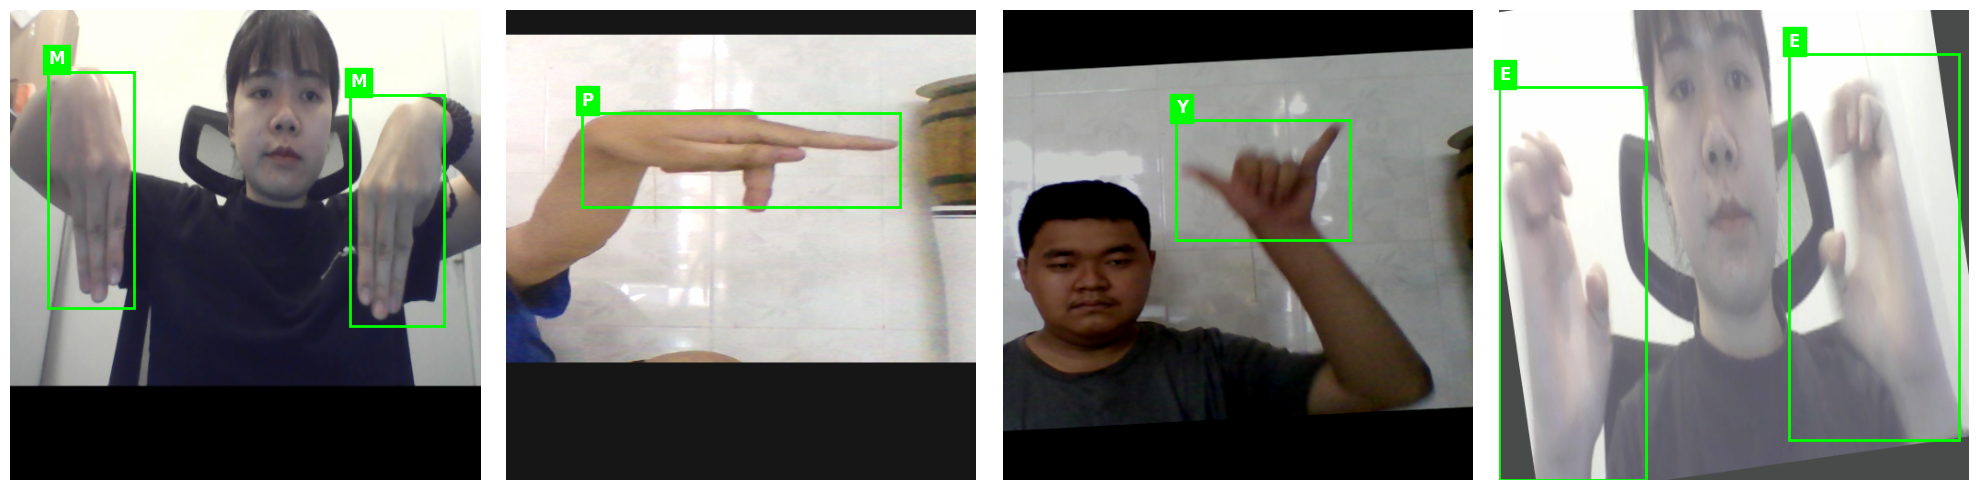

In [28]:
visualize_augmented_data(train_ds, num_samples=4)

##Training

In [29]:
# 13. TRAINING & EVALUATION LOOPS
from tqdm import tqdm

def train_one_epoch(model, dl, criterion, optimizer, scaler, device):
    model.train()
    tot = ce_tot = l1_tot = giou_tot = 0.0

    for imgs, tgts in tqdm(dl, desc="Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in tgts]

        with torch.amp.autocast('cuda'):              # fp16 forward
            outs = model(imgs)
            loss, ce, l1, giou = criterion(outs, tgts)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)       # faster than zero_grad()


        tot      += loss.item()
        ce_tot   += ce.item()
        l1_tot   += l1.item()
        giou_tot += giou.item()

    n = len(dl)
    return dict(total=tot/n, ce=ce_tot/n, bbox=l1_tot/n, giou=giou_tot/n)


@torch.no_grad()
def evaluate(model, dl, criterion, device):
    model.eval()
    tot = ce_tot = l1_tot = giou_tot = 0.0

    for imgs, tgts in tqdm(dl, desc="Valid", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in tgts]

        with torch.amp.autocast('cuda'):
            outs = model(imgs)
            loss, ce, l1, giou = criterion(outs, tgts)

        tot += loss.item(); ce_tot += ce.item()
        l1_tot += l1.item(); giou_tot += giou.item()

    n = len(dl)
    return dict(total=tot/n, ce=ce_tot/n, bbox=l1_tot/n, giou=giou_tot/n)

In [30]:
print(f"Train: {len(train_ds)} samples, {len(train_dl)} batches")
print(f"Valid: {len(valid_ds)} samples, {len(valid_dl)} batches")
print(f"Test : {len(test_ds)}  samples, {len(test_dl)}  batches")

# Kiểm tra tỉ lệ train/val
print(f"\nTỉ lệ Train/Valid: {len(train_ds)/len(valid_ds):.1f}x")

Train: 2139 samples, 66 batches
Valid: 616 samples, 20 batches
Test : 330  samples, 11  batches

Tỉ lệ Train/Valid: 3.5x


In [31]:
# 14. TRAINING LOOP
OUTPUT_DIR = '/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/resnet_v2/v2/base/output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PATIENCE = 30
no_improve_count = 0

best_model_path = os.path.join(OUTPUT_DIR, 'best_signdetr_model.pth')
history_path    = os.path.join(OUTPUT_DIR, 'training_history.json')
log_path        = os.path.join(OUTPUT_DIR, 'training_log.txt')

history      = {k: [] for k in ['train_loss','val_loss','train_ce','val_ce',
                                  'train_bbox','val_bbox','train_giou','val_giou','lr']}
best_val     = float('inf')
SAVE_FREQ    = 5

def log(msg):
    print(msg)
    with open(log_path, 'a') as f:
        f.write(msg + '\n')

log(f"Training start | ENC={ENC_LAYERS} DEC={DEC_LAYERS} Q={NUM_QUERIES} BS={BATCH_SIZE}")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    tr = train_one_epoch(model, train_dl, criterion, optimizer, scaler, device)

    vl = evaluate(model, valid_dl, criterion, device)

    scheduler.step()

    lr = optimizer.param_groups[0]['lr']

    for k, v in [('train_loss', tr['total']), ('val_loss',  vl['total']),
                  ('train_ce',  tr['ce']),    ('val_ce',    vl['ce']),
                  ('train_bbox',tr['bbox']),  ('val_bbox',  vl['bbox']),
                  ('train_giou',tr['giou']),  ('val_giou',  vl['giou']),
                  ('lr', lr)]:
        history[k].append(v)

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    note = ''
    if vl['total'] < best_val:

        best_val = vl['total']
        no_improve_count = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': best_val}, best_model_path)
        note += ' [BEST]'
    else:
        no_improve_count += 1
        if no_improve_count >= PATIENCE:
            log(f"Early stopping tại epoch {epoch+1} (no improve {PATIENCE} epochs)")
            break

    if (epoch + 1) % SAVE_FREQ == 0 or epoch == NUM_EPOCHS - 1:
        ckpt = os.path.join(OUTPUT_DIR, f'checkpoint_epoch_{epoch+1:03d}.pth')
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'loss': vl['total']}, ckpt)
        note += f' [CKP ep{epoch+1}]'

    log(f"Ep {epoch+1:03d}/{NUM_EPOCHS} | {time.time()-t0:.0f}s | LR={lr:.2e}")
    log(f"  Train: {tr['total']:.4f} (CE={tr['ce']:.4f} BBox={tr['bbox']:.4f} GIoU={tr['giou']:.4f})")
    log(f"  Valid: {vl['total']:.4f} (CE={vl['ce']:.4f} BBox={vl['bbox']:.4f} GIoU={vl['giou']:.4f}){note}")

log("Training complete.")

Training start | ENC=4 DEC=4 Q=10 BS=32


Ep 001/200 | 213s | LR=1.33e-06
  Train: 15.2917 (CE=3.1702 BBox=0.5074 GIoU=0.9666)
  Valid: 15.4338 (CE=2.9927 BBox=0.3938 GIoU=1.1576) [BEST]


Ep 002/200 | 30s | LR=2.00e-06
  Train: 13.5097 (CE=3.0882 BBox=0.3725 GIoU=0.8779)
  Valid: 15.6719 (CE=2.9723 BBox=0.3684 GIoU=1.2475)


Ep 003/200 | 31s | LR=2.67e-06
  Train: 12.2106 (CE=3.0707 BBox=0.3039 GIoU=0.7619)
  Valid: 14.7960 (CE=2.9918 BBox=0.3811 GIoU=1.1079) [BEST]


Ep 004/200 | 30s | LR=3.33e-06
  Train: 11.4913 (CE=3.0643 BBox=0.2708 GIoU=0.6867)
  Valid: 15.7820 (CE=2.9685 BBox=0.3558 GIoU=1.2846)


...

Ep 196/200 | 30s | LR=1.15e-08
  Train: 1.4282 (CE=0.2911 BBox=0.0309 GIoU=0.1013)
  Valid: 1.6466 (CE=0.3823 BBox=0.0257 GIoU=0.1163)


Ep 197/200 | 30s | LR=6.49e-09
  Train: 1.4416 (CE=0.2909 BBox=0.0310 GIoU=0.1034)
  Valid: 1.6436 (CE=0.3791 BBox=0.0256 GIoU=0.1161)


Ep 198/200 | 30s | LR=2.88e-09
  Train: 1.4382 (CE=0.2946 BBox=0.0312 GIoU=0.1017)
  Valid: 1.6416 (CE=0.3797 BBox=0.0256 GIoU=0.1157)


Ep 199/200 | 30s | LR=7.21e-10
  Train: 1.4228 (CE=0.2950 BBox=0.0301 GIoU=0.1002)
  Valid: 1.6453 (CE=0.3839 BBox=0.0255 GIoU=0.1159)


Ep 200/200 | 30s | LR=0.00e+00
  Train: 1.4429 (CE=0.2962 BBox=0.0315 GIoU=0.1023)
  Valid: 1.6420 (CE=0.3826 BBox=0.0256 GIoU=0.1159) [CKP ep200]
Training complete.


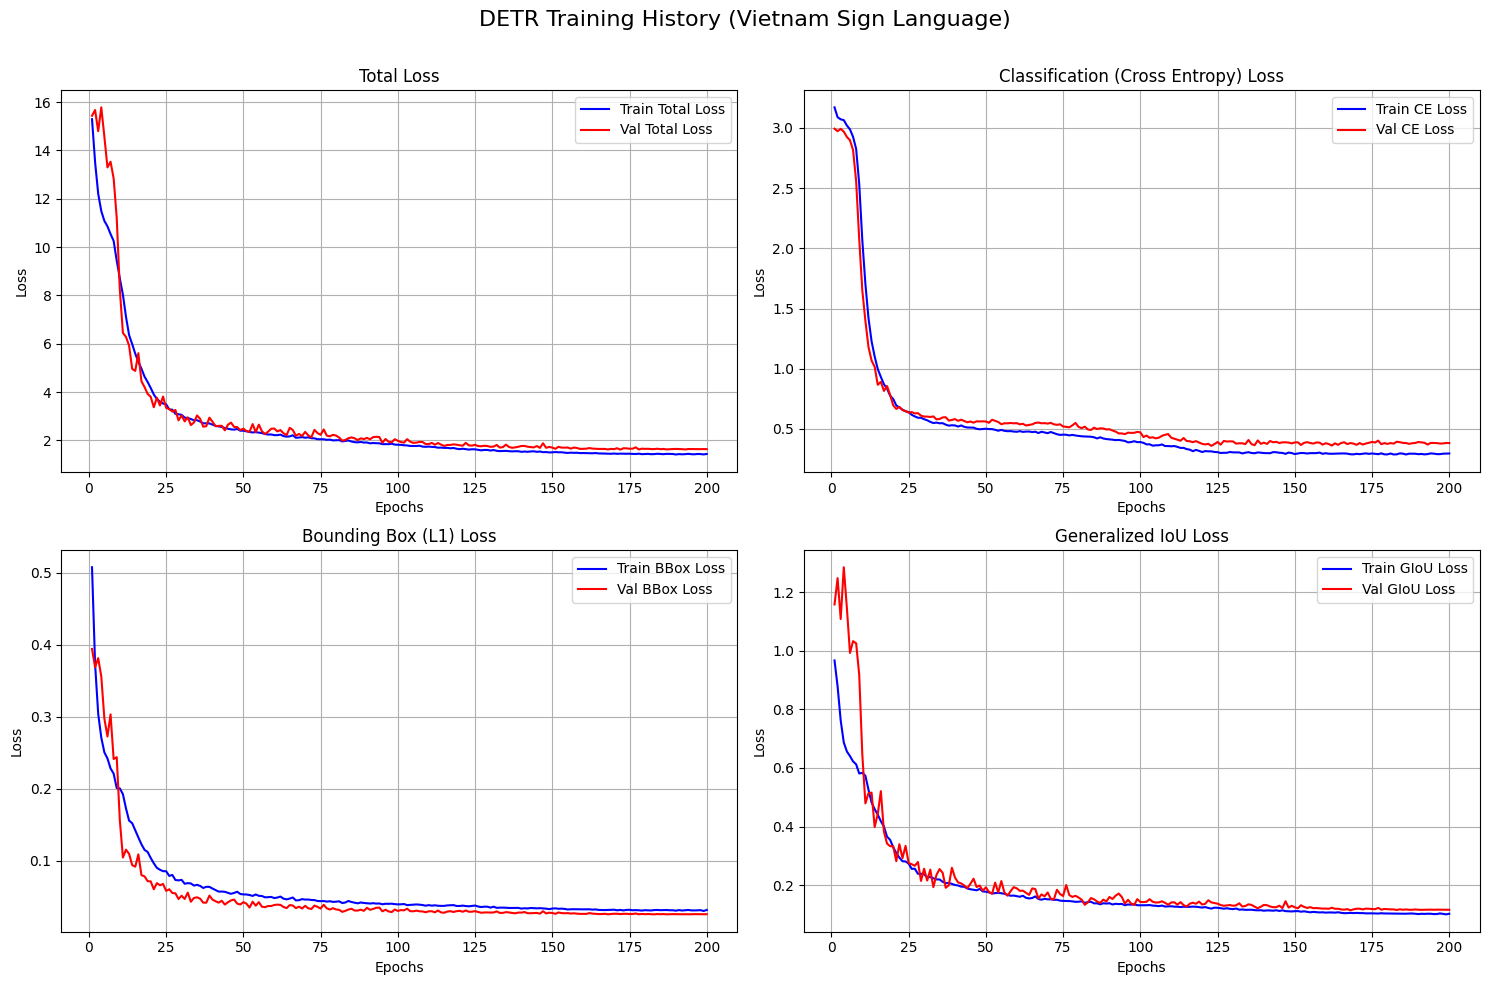

In [32]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DETR Training History (Vietnam Sign Language)', fontsize=16)

    # 1. Total Loss
    axs[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Total Loss')
    axs[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Total Loss')
    axs[0, 0].set_title('Total Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # 2. Classification Loss
    axs[0, 1].plot(epochs, history['train_ce'], 'b-', label='Train CE Loss')
    axs[0, 1].plot(epochs, history['val_ce'], 'r-', label='Val CE Loss')
    axs[0, 1].set_title('Classification (Cross Entropy) Loss')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # 3. Bounding Box L1 Loss
    axs[1, 0].plot(epochs, history['train_bbox'], 'b-', label='Train BBox Loss')
    axs[1, 0].plot(epochs, history['val_bbox'], 'r-', label='Val BBox Loss')
    axs[1, 0].set_title('Bounding Box (L1) Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # 4. GIoU Loss
    axs[1, 1].plot(epochs, history['train_giou'], 'b-', label='Train GIoU Loss')
    axs[1, 1].plot(epochs, history['val_giou'], 'r-', label='Val GIoU Loss')
    axs[1, 1].set_title('Generalized IoU Loss')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Gọi hàm để vẽ biểu đồ
plot_training_history(history)

In [33]:

# test_dataloader = DataLoader(
#     test_dataset,
#     batch_size=8,
#     collate_fn=stacker,
#     drop_last=False
# ) test_dl


In [34]:
MODEL_PATH = "/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/resnet_v2/v2/base/output/best_signdetr_model.pth"


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Khởi tạo mô hình
model = DETR(
    num_classes=NUM_CLASSES,
    hidden_dim=HIDDEN_DIM,
    nheads=NHEADS,
    num_encoder_layers=ENC_LAYERS,
    num_decoder_layers=DEC_LAYERS,
    num_queries=NUM_QUERIES,
    dim_feedforward=DIM_FF,
    dropout=DROPOUT
)

# 2. Đọc file checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

# ==========================================
# 3. FIX LỖI TORCH.COMPILE: Lọc bỏ tiền tố '_orig_mod.'
# ==========================================
clean_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('_orig_mod.'):
        clean_state_dict[k.replace('_orig_mod.', '')] = v
    else:
        clean_state_dict[k] = v

# 4. Load trọng số đã làm sạch vào mô hình
model.load_state_dict(clean_state_dict)
model.to(device)
model.eval()

print("Mô hình đã sẵn sàng.")

/tmp/ipykernel_4720/574338059.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,


Mô hình đã sẵn sàng.


In [36]:

import torch
import torch.nn.functional as F
from tqdm import tqdm
import time
@torch.no_grad()
def calculate_accuracy_and_deviation(
    model,
    dataloader,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
):
    model.eval()

    total_matched_objects = 0
    correct_top1_predictions = 0
    correct_topk_predictions = 0
    confident_objects = 0
    confident_correct_top1 = 0
    confidence_sum = 0.0

    iou_sum = 0.0
    iou_pass_count = 0

    total_box_deviation = 0.0

    # Biến để lưu sai số riêng cho từng thành phần (Tùy chọn xem chi tiết)
    dev_cx, dev_cy, dev_w, dev_h = 0.0, 0.0, 0.0, 0.0

    num_classes = None
    class_total = None
    class_correct = None

    pbar = tqdm(dataloader, desc="Calculating Accuracy & Deviation")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 1. Chạy model để lấy dự đoán
        outputs = model(images)

        # 2. Dùng HungarianMatcher để tìm ra các dự đoán khớp với Ground Truth nhất
        indices = matcher(outputs, targets)

        if num_classes is None:
            # outputs['pred_logits'] includes no-object at the last index
            num_classes = outputs['pred_logits'].shape[-1] - 1
            class_total = [0 for _ in range(num_classes)]
            class_correct = [0 for _ in range(num_classes)]

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            # Lấy ra các dự đoán và đáp án đã được ghép cặp (matched)
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- TÍNH ACCURACY (Top-1, Top-k, confidence threshold) ---
            class_probs = pred_logits_matched.softmax(dim=-1)[:, :-1]  # drop no-object class
            conf_scores, pred_labels = class_probs.max(dim=-1)

            k_val = min(topk, class_probs.shape[-1])
            topk_labels = class_probs.topk(k=k_val, dim=-1).indices

            is_top1_correct = pred_labels == tgt_labels_matched
            is_topk_correct = (topk_labels == tgt_labels_matched.unsqueeze(1)).any(dim=1)
            confident_mask = conf_scores >= conf_threshold

            correct_top1_predictions += is_top1_correct.sum().item()
            correct_topk_predictions += is_topk_correct.sum().item()
            confident_objects += confident_mask.sum().item()
            confident_correct_top1 += (is_top1_correct & confident_mask).sum().item()
            confidence_sum += conf_scores.sum().item()

            for gt_label, is_correct in zip(tgt_labels_matched, is_top1_correct):
                gt_id = int(gt_label.item())
                if 0 <= gt_id < num_classes:
                    class_total[gt_id] += 1
                    if bool(is_correct.item()):
                        class_correct[gt_id] += 1

            # --- TÍNH mIoU + tỉ lệ IoU đạt ngưỡng ---
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            iou_sum += matched_iou.sum().item()
            iou_pass_count += (matched_iou >= iou_threshold).sum().item()

            # --- TÍNH ĐỘ LỆCH (Box Deviation - L1 Error) ---
            # Tính sai số tuyệt đối trung bình cho 4 tọa độ (cx, cy, w, h)
            # Tọa độ đang ở dạng chuẩn hóa (0 -> 1)
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # Tính sai số chi tiết cho tâm (cx, cy) và kích thước (w, h)
            abs_diff = torch.abs(pred_boxes_matched - tgt_boxes_matched)
            dev_cx += abs_diff[:, 0].sum().item()
            dev_cy += abs_diff[:, 1].sum().item()
            dev_w  += abs_diff[:, 2].sum().item()
            dev_h  += abs_diff[:, 3].sum().item()

    # Tổng hợp kết quả
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return {}

    top1_accuracy = (correct_top1_predictions / total_matched_objects) * 100
    topk_accuracy = (correct_topk_predictions / total_matched_objects) * 100
    confident_accuracy = (
        (confident_correct_top1 / confident_objects) * 100 if confident_objects > 0 else 0.0
    )
    avg_confidence = confidence_sum / total_matched_objects
    mean_iou = iou_sum / total_matched_objects
    iou_pass_rate = (iou_pass_count / total_matched_objects) * 100

    # Chia cho (số object * 4 tọa độ) để ra độ lệch trung bình trên mỗi trục tọa độ
    avg_deviation = total_box_deviation / (total_matched_objects * 4)

    avg_dev_cx = dev_cx / total_matched_objects
    avg_dev_cy = dev_cy / total_matched_objects
    avg_dev_w  = dev_w / total_matched_objects
    avg_dev_h  = dev_h / total_matched_objects

    print("\n" + "="*50)
    print(" KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST ".center(50))
    print("="*50)
    print(f"Tổng số đối tượng được test : {total_matched_objects}")
    print(f"Top-1 Accuracy             : {top1_accuracy:.2f}% ({correct_top1_predictions}/{total_matched_objects})")
    print(f"Top-{min(topk, num_classes)} Accuracy           : {topk_accuracy:.2f}% ({correct_topk_predictions}/{total_matched_objects})")
    print(f"Confident Top-1 Accuracy   : {confident_accuracy:.2f}% (thr={conf_threshold}, {confident_correct_top1}/{confident_objects})")
    print(f"Mean confidence            : {avg_confidence:.4f}")
    print(f"Mean IoU                   : {mean_iou:.4f}")
    print(f"IoU@{iou_threshold} pass rate     : {iou_pass_rate:.2f}% ({iou_pass_count}/{total_matched_objects})")
    print("-" * 50)
    print(f"Độ lệch tổng thể (Trung bình): {avg_deviation:.4f} (theo tỷ lệ ảnh 0-1)")
    print("Chi tiết độ lệch từng thông số:")
    print(f"  - Lệch tọa độ X (cx)       : {avg_dev_cx:.4f} (~{avg_dev_cx*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch tọa độ Y (cy)       : {avg_dev_cy:.4f} (~{avg_dev_cy*100:.2f}% chiều cao ảnh)")
    print(f"  - Lệch chiều rộng (w)      : {avg_dev_w:.4f}  (~{avg_dev_w*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch chiều cao (h)       : {avg_dev_h:.4f}  (~{avg_dev_h*100:.2f}% chiều cao ảnh)")

    if class_total is not None and class_correct is not None:
        per_class_stats = []
        for cls_id in range(num_classes):
            total_cls = class_total[cls_id]
            if total_cls == 0:
                continue
            acc_cls = 100.0 * class_correct[cls_id] / total_cls
            per_class_stats.append((cls_id, acc_cls, class_correct[cls_id], total_cls))

        if per_class_stats:
            per_class_stats.sort(key=lambda x: x[1])
            print("-" * 50)
            print("5 lớp yếu nhất (Top-1):")
            for cls_id, acc_cls, c_ok, c_total in per_class_stats[:5]:
                print(f"  - Class {cls_id:>2}: {acc_cls:6.2f}% ({c_ok}/{c_total})")

    print("="*50)

    return {
        "total_objects": total_matched_objects,
        "top1_accuracy": top1_accuracy,
        "topk_accuracy": topk_accuracy,
        "confident_accuracy": confident_accuracy,
        "mean_confidence": avg_confidence,
        "mean_iou": mean_iou,
        "iou_pass_rate": iou_pass_rate,
        "avg_deviation": avg_deviation,
        "avg_dev_cx": avg_dev_cx,
        "avg_dev_cy": avg_dev_cy,
        "avg_dev_w": avg_dev_w,
        "avg_dev_h": avg_dev_h,
    }

# Gọi hàm để tính toán
eval_stats = calculate_accuracy_and_deviation(
    model,
    test_dl,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
)


def _ap_from_ranked_predictions(records, num_gt):
    """Compute AP from ranked predictions.

    records: list of tuples (score, tp, fp)
    num_gt: number of GT objects for this class (or class-size group)
    """
    if num_gt <= 0:
        return None
    if not records:
        return 0.0

    records = sorted(records, key=lambda x: x[0], reverse=True)
    tps = np.array([r[1] for r in records], dtype=np.float32)
    fps = np.array([r[2] for r in records], dtype=np.float32)

    tp_cum = np.cumsum(tps)
    fp_cum = np.cumsum(fps)

    recalls = tp_cum / max(float(num_gt), 1e-12)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-12)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    # Precision envelope
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return float(ap)


def _mask_by_area_bin(areas, bin_name, small_thr, medium_thr):
    if bin_name == "small":
        return areas < small_thr
    if bin_name == "medium":
        return (areas >= small_thr) & (areas < medium_thr)
    return areas >= medium_thr


@torch.no_grad()
def calculate_map_metrics(
    model,
    dataloader,
    device,
    score_threshold=0.05,
    iou_thresholds=None,
    input_size_for_bins=512,
):
    """Compute COCO-style metrics (approx): mAP, AP50, AP75, AP by object size."""
    model.eval()

    if iou_thresholds is None:
        iou_thresholds = [round(x, 2) for x in np.arange(0.50, 0.96, 0.05)]

    # COCO-like object size thresholds, converted to normalized area
    img_area = float(input_size_for_bins * input_size_for_bins)
    small_thr = (32.0 * 32.0) / img_area
    medium_thr = (96.0 * 96.0) / img_area

    num_classes = None

    records = {}  # records[iou][class] -> [(score, tp, fp), ...]
    gt_counts = {}  # gt_counts[class]

    size_bins = ("small", "medium", "large")
    records_by_size = {b: {} for b in size_bins}
    gt_counts_by_size = {b: {} for b in size_bins}

    for images, targets in tqdm(dataloader, desc="Calculating mAP/AP"):
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        if num_classes is None:
            num_classes = outputs["pred_logits"].shape[-1] - 1
            for thr in iou_thresholds:
                records[thr] = {c: [] for c in range(num_classes)}
                for b in size_bins:
                    records_by_size[b][thr] = {c: [] for c in range(num_classes)}
            gt_counts = {c: 0 for c in range(num_classes)}
            for b in size_bins:
                gt_counts_by_size[b] = {c: 0 for c in range(num_classes)}

        batch_size = images.shape[0]
        for b_idx in range(batch_size):
            logits = outputs["pred_logits"][b_idx]
            pred_boxes = outputs["pred_boxes"][b_idx]

            probs = logits.softmax(dim=-1)[:, :-1]  # exclude no-object class
            pred_scores, pred_labels = probs.max(dim=-1)
            keep = pred_scores >= score_threshold

            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]
            pred_boxes = pred_boxes[keep]

            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes)
            pred_areas = ((pred_xyxy[:, 2] - pred_xyxy[:, 0]).clamp(min=0.0) *
                          (pred_xyxy[:, 3] - pred_xyxy[:, 1]).clamp(min=0.0))

            gt_labels = targets[b_idx]["labels"].long()
            gt_boxes = targets[b_idx]["boxes"].float()
            gt_xyxy = box_cxcywh_to_xyxy(gt_boxes)
            gt_areas = ((gt_xyxy[:, 2] - gt_xyxy[:, 0]).clamp(min=0.0) *
                        (gt_xyxy[:, 3] - gt_xyxy[:, 1]).clamp(min=0.0))

            for cls_id in range(num_classes):
                cls_pred_mask = pred_labels == cls_id
                cls_gt_mask = gt_labels == cls_id

                cls_pred_scores = pred_scores[cls_pred_mask]
                cls_pred_boxes = pred_xyxy[cls_pred_mask]
                cls_pred_areas = pred_areas[cls_pred_mask]

                cls_gt_boxes = gt_xyxy[cls_gt_mask]
                cls_gt_areas = gt_areas[cls_gt_mask]

                num_gt = int(cls_gt_boxes.shape[0])
                gt_counts[cls_id] += num_gt

                for bname in size_bins:
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)
                    gt_counts_by_size[bname][cls_id] += int(gt_bin_mask.sum().item())

                if cls_pred_scores.numel() > 0:
                    order = torch.argsort(cls_pred_scores, descending=True)
                    cls_pred_scores = cls_pred_scores[order]
                    cls_pred_boxes = cls_pred_boxes[order]
                    cls_pred_areas = cls_pred_areas[order]

                # Global AP per class
                for thr in iou_thresholds:
                    matched_gt = set()
                    for p_i in range(cls_pred_boxes.shape[0]):
                        score = float(cls_pred_scores[p_i].item())

                        if num_gt == 0:
                            records[thr][cls_id].append((score, 0, 1))
                            continue

                        ious, _ = box_iou(cls_pred_boxes[p_i].unsqueeze(0), cls_gt_boxes)
                        ious = ious[0]
                        best_iou, best_j = torch.max(ious, dim=0)
                        best_iou = float(best_iou.item())
                        best_j = int(best_j.item())

                        if best_iou >= thr and best_j not in matched_gt:
                            matched_gt.add(best_j)
                            records[thr][cls_id].append((score, 1, 0))
                        else:
                            records[thr][cls_id].append((score, 0, 1))

                # AP by size bin (approx): evaluate predictions and GT in the same area bin
                for bname in size_bins:
                    pred_bin_mask = _mask_by_area_bin(cls_pred_areas, bname, small_thr, medium_thr)
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)

                    pred_scores_bin = cls_pred_scores[pred_bin_mask]
                    pred_boxes_bin = cls_pred_boxes[pred_bin_mask]
                    gt_boxes_bin = cls_gt_boxes[gt_bin_mask]

                    num_gt_bin = int(gt_boxes_bin.shape[0])

                    for thr in iou_thresholds:
                        matched_gt_bin = set()
                        for p_i in range(pred_boxes_bin.shape[0]):
                            score = float(pred_scores_bin[p_i].item())

                            if num_gt_bin == 0:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))
                                continue

                            ious, _ = box_iou(pred_boxes_bin[p_i].unsqueeze(0), gt_boxes_bin)
                            ious = ious[0]
                            best_iou, best_j = torch.max(ious, dim=0)
                            best_iou = float(best_iou.item())
                            best_j = int(best_j.item())

                            if best_iou >= thr and best_j not in matched_gt_bin:
                                matched_gt_bin.add(best_j)
                                records_by_size[bname][thr][cls_id].append((score, 1, 0))
                            else:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))

    if num_classes is None:
        print("No predictions found for mAP calculation")
        return {}

    def mean_ap_at_threshold(thr, rec_dict, gt_dict):
        aps = []
        for c in range(num_classes):
            ap = _ap_from_ranked_predictions(rec_dict[thr][c], gt_dict[c])
            if ap is not None:
                aps.append(ap)
        return float(np.mean(aps)) if aps else 0.0

    ap50 = mean_ap_at_threshold(0.50, records, gt_counts)
    ap75 = mean_ap_at_threshold(0.75, records, gt_counts)

    map_per_thr = [mean_ap_at_threshold(thr, records, gt_counts) for thr in iou_thresholds]
    map_50_95 = float(np.mean(map_per_thr)) if map_per_thr else 0.0

    ap_by_size = {}
    for bname in size_bins:
        vals = [
            mean_ap_at_threshold(thr, records_by_size[bname], gt_counts_by_size[bname])
            for thr in iou_thresholds
        ]
        ap_by_size[bname] = float(np.mean(vals)) if vals else 0.0

    print("\n" + "=" * 62)
    print(" DETECTION METRICS (COCO-STYLE APPROX) ".center(62))
    print("=" * 62)
    print(f"mAP@[0.50:0.95] : {map_50_95 * 100:.2f}")
    print(f"AP50            : {ap50 * 100:.2f}")
    print(f"AP75            : {ap75 * 100:.2f}")
    print(f"AP small        : {ap_by_size['small'] * 100:.2f}")
    print(f"AP medium       : {ap_by_size['medium'] * 100:.2f}")
    print(f"AP large        : {ap_by_size['large'] * 100:.2f}")
    print("=" * 62)

    return {
        "mAP_50_95": map_50_95,
        "AP50": ap50,
        "AP75": ap75,
        "AP_small": ap_by_size["small"],
        "AP_medium": ap_by_size["medium"],
        "AP_large": ap_by_size["large"],
    }


@torch.no_grad()
def measure_efficiency_metrics(model, dataloader, device, warmup_steps=10, measure_steps=50):
    """Measure FPS, latency, parameter count, and estimate GFLOPs."""
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Estimate GFLOPs if torchinfo is available
    gflops_est = None
    try:
        from torchinfo import summary as torchinfo_summary
        stats = torchinfo_summary(model, input_size=(1, 3, 512, 512), verbose=0)
        if getattr(stats, "total_mult_adds", None) is not None:
            # total_mult_adds is MACs, commonly reported as FLOPs in quick model audits
            gflops_est = float(stats.total_mult_adds) / 1e9
    except Exception:
        gflops_est = None

    # Warmup
    step = 0
    for images, _ in dataloader:
        images = images.to(device)
        _ = model(images)
        step += 1
        if step >= warmup_steps:
            break

    # Timed inference
    start_t = time.time()
    measured_steps = 0
    measured_images = 0
    for images, _ in dataloader:
        images = images.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()

        measured_steps += 1
        measured_images += int(images.shape[0])
        if measured_steps >= measure_steps:
            break

    elapsed = max(time.time() - start_t, 1e-12)
    fps = measured_images / elapsed
    latency_ms = (elapsed / measured_images) * 1000.0

    print("\n" + "=" * 62)
    print(" EFFICIENCY METRICS ".center(62))
    print("=" * 62)
    print(f"Parameters (total)   : {total_params:,}")
    print(f"Parameters (train)   : {trainable_params:,}")
    print(f"GFLOPs (est.)        : {gflops_est:.2f}" if gflops_est is not None else "GFLOPs (est.)        : N/A")
    print(f"FPS                  : {fps:.2f}")
    print(f"Latency / image (ms) : {latency_ms:.2f}")
    print("=" * 62)

    return {
        "params_total": total_params,
        "params_trainable": trainable_params,
        "gflops_est": gflops_est,
        "fps": fps,
        "latency_ms": latency_ms,
    }


map_stats = calculate_map_metrics(
    model,
    test_dl,
    device,
    score_threshold=0.05,
    iou_thresholds=[round(x, 2) for x in np.arange(0.50, 0.96, 0.05)],
    input_size_for_bins=512,
)

eff_stats = measure_efficiency_metrics(
    model,
    test_dl,
    device,
    warmup_steps=10,
    measure_steps=50,
)






Calculating Accuracy & Deviation: 100%|██████████| 11/11 [00:05<00:00,  2.17it/s]



     KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST     
Tổng số đối tượng được test : 481
Top-1 Accuracy             : 97.92% (471/481)
Top-3 Accuracy           : 99.58% (479/481)
Confident Top-1 Accuracy   : 98.94% (thr=0.35, 467/472)
Mean confidence            : 0.9064
Mean IoU                   : 0.8880
IoU@0.5 pass rate     : 99.79% (480/481)
--------------------------------------------------
Độ lệch tổng thể (Trung bình): 0.0062 (theo tỷ lệ ảnh 0-1)
Chi tiết độ lệch từng thông số:
  - Lệch tọa độ X (cx)       : 0.0040 (~0.40% chiều rộng ảnh)
  - Lệch tọa độ Y (cy)       : 0.0046 (~0.46% chiều cao ảnh)
  - Lệch chiều rộng (w)      : 0.0078  (~0.78% chiều rộng ảnh)
  - Lệch chiều cao (h)       : 0.0082  (~0.82% chiều cao ảnh)
--------------------------------------------------
5 lớp yếu nhất (Top-1):
  - Class 18:  85.00% (17/20)
  - Class  8:  90.48% (19/21)
  - Class  7:  95.00% (19/20)
  - Class  9:  95.24% (20/21)
  - Class 10:  95.24% (20/21)


Calculating mAP/AP: 100%|██████████| 11/11 [00:22<00:00,  2.01s/it]



            DETECTION METRICS (COCO-STYLE APPROX)             
mAP@[0.50:0.95] : 44.45
AP50            : 56.14
AP75            : 54.67
AP small        : 0.00
AP medium       : 39.35
AP large        : 50.86

                      EFFICIENCY METRICS                      
Parameters (total)   : 31,547,995
Parameters (train)   : 31,547,995
GFLOPs (est.)        : 21.49
FPS                  : 146.30
Latency / image (ms) : 6.84


In [37]:

import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def calculate_advanced_metrics(model, dataloader, matcher, device, id2name):
    model.eval()

    total_matched_objects = 0
    correct_class_predictions = 0
    total_box_deviation = 0.0
    total_iou = 0.0

    # Dictionary để theo dõi số lượng và độ chính xác của từng chữ cái
    class_totals = {i: 0 for i in id2name.keys()}
    class_corrects = {i: 0 for i in id2name.keys()}

    pbar = tqdm(dataloader, desc="Calculating Advanced Metrics")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        indices = matcher(outputs, targets)

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- 1. TÍNH ACCURACY & PER-CLASS ACCURACY ---
            pred_labels = pred_logits_matched.argmax(dim=-1)
            correct_mask = (pred_labels == tgt_labels_matched)
            correct_class_predictions += correct_mask.sum().item()

            # Thống kê chi tiết cho từng chữ cái
            for p_label, t_label, is_correct in zip(pred_labels, tgt_labels_matched, correct_mask):
                t_id = t_label.item()
                if t_id in class_totals:
                    class_totals[t_id] += 1
                    if is_correct.item():
                        class_corrects[t_id] += 1

            # --- 2. TÍNH ĐỘ LỆCH (L1 Deviation) ---
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # --- 3. TÍNH mIoU (mean Intersection over Union) ---
            # Chuyển đổi về dạng [x1, y1, x2, y2] để tính IoU
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)

            # Hàm box_iou trả về ma trận NxN, ta lấy đường chéo (diag) vì các box đã được match 1-1
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            total_iou += matched_iou.sum().item()

    # ================= HIỂN THỊ KẾT QUẢ =================
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return

    accuracy = (correct_class_predictions / total_matched_objects) * 100
    avg_deviation = total_box_deviation / (total_matched_objects * 4)
    mIoU = (total_iou / total_matched_objects) * 100

    print("\n" + "="*50)
    print(" BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL ".center(50))
    print("="*50)
    print(f"Tổng số bàn tay được test: {total_matched_objects}")
    print(f"1. Độ chính xác tổng thể : {accuracy:.2f}%")
    print(f"2. Độ lệch tọa độ (L1)   : {avg_deviation:.4f}")
    print(f"3. Chỉ số mIoU (Độ khớp) : {mIoU:.2f}% (Càng gần 100% khung hình càng ôm sát tay)")
    print("-" * 50)

    print("4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):")
    # Sắp xếp các class theo độ chính xác từ thấp đến cao để dễ tìm lỗi
    class_accuracies = []
    for cls_id, total in class_totals.items():
        if total > 0:
            acc = (class_corrects[cls_id] / total) * 100
            class_accuracies.append((id2name[cls_id], acc, class_corrects[cls_id], total))

    class_accuracies.sort(key=lambda x: x[1]) # Sắp xếp tăng dần theo accuracy

    for name, acc, correct, total in class_accuracies:
        # Highlight những chữ cái nhận diện kém (< 70%)
        warning = " ⚠️ Cần thêm data" if acc < 70 else ""
        print(f"   - Chữ {name:<3} : {acc:6.2f}% ({correct}/{total}){warning}")
    print("="*50)

# Gọi hàm (nhớ truyền biến id2name vào)
# calculate_advanced_metrics(model, test_dataloader, matcher, device, id2name)

calculate_advanced_metrics(model, test_dl, matcher, device, id2name)

Calculating Advanced Metrics: 100%|██████████| 11/11 [00:03<00:00,  3.66it/s]


      BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL      
Tổng số bàn tay được test: 481
1. Độ chính xác tổng thể : 97.30%
2. Độ lệch tọa độ (L1)   : 0.0062
3. Chỉ số mIoU (Độ khớp) : 88.80% (Càng gần 100% khung hình càng ôm sát tay)
--------------------------------------------------
4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):
   - Chữ U   :  85.00% (17/20)
   - Chữ K   :  90.48% (19/21)
   - Chữ R   :  91.30% (21/23)
   - Chữ V   :  91.30% (21/23)
   - Chữ I   :  95.00% (19/20)
   - Chữ L   :  95.24% (20/21)
   - Chữ M   :  95.24% (20/21)
   - Chữ G   :  95.45% (21/22)
   - Chữ A   : 100.00% (23/23)
   - Chữ B   : 100.00% (23/23)
   - Chữ C   : 100.00% (21/21)
   - Chữ D   : 100.00% (22/22)
   - Chữ E   : 100.00% (23/23)
   - Chữ H   : 100.00% (25/25)
   - Chữ N   : 100.00% (21/21)
   - Chữ O   : 100.00% (23/23)
   - Chữ P   : 100.00% (22/22)
   - Chữ Q   : 100.00% (21/21)
   - Chữ S   : 100.00% (24/24)
   - Chữ T   : 100.00% (21/21)
   - Chữ X   : 100.00% (23/23)
   - Chữ Y 

In [ ]:
import os
import signal

# Đặt dòng này ở cuối cùng của notebooka
print("Ngắt tiến trình...")
os.kill(os.getpid(), signal.SIGKILL)